About Dataset
The aug_train.csv dataset provides a structured view of job seekers’ demographic, educational, and professional attributes, making it highly relevant for predictive modeling in human resources and career analytics. Each row corresponds to an individual candidate, uniquely identified by an enrollee_id. The dataset captures geographic information through the city variable and a city_development_index, which quantifies the socio-economic development level of the candidate’s location. This allows researchers to explore how urban development influences employment opportunities.
Personal characteristics such as gender and relevent_experience highlight diversity and prior exposure to the workforce. The dataset also records whether candidates are currently enrolled in a university (enrolled_university) and their highest education_level, ranging from high school to graduate and master’s degrees. The major_discipline column specifies the field of study, including STEM, Humanities, and other disciplines, enabling comparative analysis across academic backgrounds. These features provide a foundation for examining how education and specialization affect career trajectories.
Beyond education and demographics, the dataset includes variables related to employment history, company size, last job change, and other career-related factors. Together, these attributes make the dataset suitable for tasks such as predicting job changes, analyzing career paths, and building machine learning models for HR decision-making. Its balanced mix of categorical and numerical variables supports both statistical analysis and advanced modeling techniques.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [28]:
df = pd.read_csv('aug_train.csv')
df.shape

(19158, 14)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 2.

In [30]:
df.isna().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     0.000000
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
last_new_job               2.207955
training_hours             0.000000
target                     0.000000
dtype: float64

In [31]:
df.gender = df.gender.fillna('not_stated')

In [32]:
vc = df[
    df.select_dtypes(include='object').columns
].value_counts().reset_index()

vc

/tmp/ipykernel_293946/1730089142.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,count
0,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,47
1,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,100-500,Pvt Ltd,>4,26
2,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,1000-4999,Pvt Ltd,>4,26
3,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,>4,24
4,city_103,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,10000+,Pvt Ltd,>4,15
...,...,...,...,...,...,...,...,...,...,...,...
9595,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,500-999,Pvt Ltd,1,1
9596,city_21,Male,No relevent experience,Full time course,Graduate,STEM,1,100-500,Pvt Ltd,1,1
9597,city_21,not_stated,Has relevent experience,no_enrollment,Masters,STEM,3,100-500,Pvt Ltd,3,1
9598,city_160,Female,Has relevent experience,no_enrollment,Graduate,STEM,10,100-500,Public Sector,3,1


In [33]:
df['no_job_info'] = (df.company_type.isna() & df.company_size.isna()).astype(int)
df.no_job_info.value_counts()

no_job_info
0    13798
1     5360
Name: count, dtype: int64

In [34]:
df.enrolled_university = df.enrolled_university.fillna('not_stated')

In [35]:
import numpy as np

education_map = {np.nan : 0 ,'Primary School': 1,'High School': 2, 'Graduate': 3, 'Masters': 4, 'Phd': 5}

df.education_level = df.education_level.map(education_map)

In [36]:
df.major_discipline = df.major_discipline.fillna('not_stated')

df.major_discipline.value_counts(dropna=False)

major_discipline
STEM               14492
not_stated          2813
Humanities           669
Other                381
Business Degree      327
Arts                 253
No Major             223
Name: count, dtype: int64

In [38]:
df = df.drop_duplicates()

Удаление колонки enrolle_id
У нас уже есть индекс, поэтому для работы регрессии нам не нужен уникальный идентификатор PID.

In [ ]:
# df = df.drop('enrollee_id',axis=1)
# df = df.drop('city',axis=1)

In [39]:
# len(df.columns)

## Признаки со значениями NaN

In [42]:
100* df.isnull().sum() / len(df)

enrollee_id                0.000000
city                       0.000000
city_development_index     0.000000
gender                     0.000000
relevent_experience        0.000000
enrolled_university        0.000000
education_level            0.000000
major_discipline           0.000000
experience                 0.339284
company_size              30.994885
company_type              32.049274
last_new_job               2.207955
training_hours             0.000000
target                     0.000000
no_job_info                0.000000
dtype: float64

## Доля строк с пропусками

In [43]:
total_null_percent = df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100
total_null_percent

np.float64(4.372759856630824)

# Содзадим свою функцию для вычисления % пропущенных данных

In [44]:
def percent_missing(df):
    percent_nan = 100* df.isnull().sum() / len(df)
    percent_nan = percent_nan[percent_nan>0].sort_values()
    return percent_nan

In [45]:
percent_nan = percent_missing(df)

In [46]:
percent_nan

experience       0.339284
last_new_job     2.207955
company_size    30.994885
company_type    32.049274
dtype: float64

In [47]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,no_job_info
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,>20,NaN,NaN,1,36,1.0,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,3,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0
2,11561,city_21,0.624,not_stated,No relevent experience,Full time course,3,STEM,5,NaN,NaN,never,83,0.0,1
3,33241,city_115,0.789,not_stated,No relevent experience,not_stated,3,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,4,STEM,>20,50-99,Funded Startup,4,8,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,3,Humanities,14,NaN,NaN,1,42,1.0,1
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,14,NaN,NaN,4,52,1.0,1
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,>20,50-99,Pvt Ltd,4,44,0.0,0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,2,not_stated,<1,500-999,Pvt Ltd,2,97,0.0,0


In [48]:
df[df.company_type.isna()&df.company_size.isna()]

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,no_job_info
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,>20,NaN,NaN,1,36,1.0,1
2,11561,city_21,0.624,not_stated,No relevent experience,Full time course,3,STEM,5,NaN,NaN,never,83,0.0,1
5,21651,city_176,0.764,not_stated,Has relevent experience,Part time course,3,STEM,11,NaN,NaN,1,24,1.0,1
10,29452,city_21,0.624,not_stated,No relevent experience,Full time course,2,not_stated,2,NaN,NaN,never,32,1.0,1
13,5826,city_21,0.624,Male,No relevent experience,not_stated,0,not_stated,2,NaN,NaN,never,24,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19144,17191,city_21,0.624,not_stated,No relevent experience,Full time course,3,STEM,4,NaN,NaN,never,48,1.0,1
19151,11385,city_149,0.689,Male,No relevent experience,Full time course,3,not_stated,2,NaN,NaN,1,60,0.0,1
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,3,Humanities,14,NaN,NaN,1,42,1.0,1
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,14,NaN,NaN,4,52,1.0,1


([0, 1, 2, 3],
 [Text(0, 0, 'experience'),
  Text(1, 0, 'last_new_job'),
  Text(2, 0, 'company_size'),
  Text(3, 0, 'company_type')])

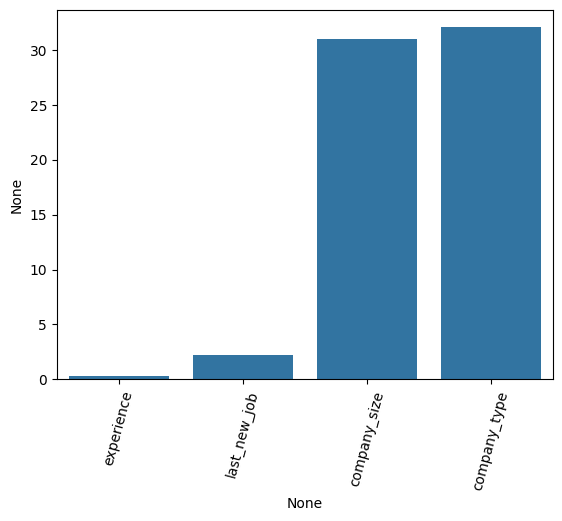

In [49]:
sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=75)

Если `last_new_job` равно `never`, значит, у человека не было предыдущего места работы; если, кроме того, `company_type` равно `null`, это означает, что он никогда не работал.

Если `last_new_job` равно `never`, значит, у человека не было предыдущего места работы; если, кроме того, `company_type` равно `!= null`, это означает, что он в настоящее время работает на своей первой работе.

По этой причине допустимо значение `null` в `last_new_job`, `company_type` и `company_size`.

Столбец `gender` содержит значения `null`; его можно удалить в зависимости от конкретного случая.

Столбец `major_discipline` связан с `education_level`. Если `major_discipline` равно `null`, это означает, что человек не окончил университет. С другой стороны, если `education_level` ниже профессионального образования, `major_discipline` имеет значение `null`.

`enrolled_university` и `education_level` являются кандидатами на удаление значений `null`.

Если `education_level` ниже `University`, в наборе данных отображается `no_enrollment`.

`education_level` всегда показывает наивысший достигнутый уровень образования; если он отсутствует, это означает, что у человека нет формального образования.

``` Наконец, `experience` может быть заполнено значением 0, указывающим на общее количество лет опыта работы; значение `null` может означать 0 лет.

In [50]:
df['last_new_job'].unique()


<StringArray>
['1', '>4', 'never', '4', '3', '2', nan]
Length: 7, dtype: str

In [51]:
df.select_dtypes(include='object').columns

/tmp/ipykernel_293946/3732952691.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['city', 'gender', 'relevent_experience', 'enrolled_university',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job'],
      dtype='str')

In [52]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,no_job_info
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,>20,NaN,NaN,1,36,1.0,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,3,STEM,15,50-99,Pvt Ltd,>4,47,0.0,0
2,11561,city_21,0.624,not_stated,No relevent experience,Full time course,3,STEM,5,NaN,NaN,never,83,0.0,1
3,33241,city_115,0.789,not_stated,No relevent experience,not_stated,3,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,4,STEM,>20,50-99,Funded Startup,4,8,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,3,Humanities,14,NaN,NaN,1,42,1.0,1
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,14,NaN,NaN,4,52,1.0,1
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,3,STEM,>20,50-99,Pvt Ltd,4,44,0.0,0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,2,not_stated,<1,500-999,Pvt Ltd,2,97,0.0,0


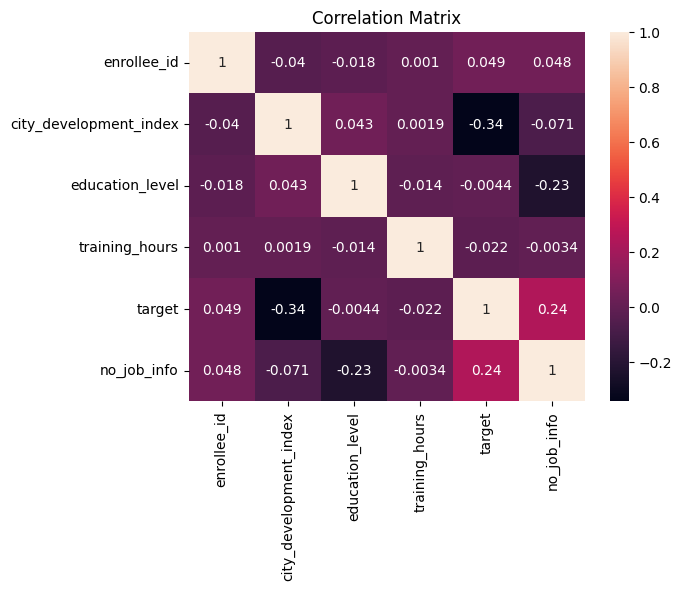

In [53]:
numeric_cols = df.select_dtypes(include=['number']).columns
sns.heatmap(df[numeric_cols].corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

In [54]:
import os
import json
import numpy as np
import pandas as pd

# # =========================
# # 0) Load
# # =========================
# df = pd.read_csv("./aug_train.csv")
# print("Raw shape:", df.shape)

# =========================
# 1) Helpers
# =========================
def pct(x: float) -> float:
    return float(np.round(x * 100, 2))

def top_missing_cols(df: pd.DataFrame, n: int = 5) -> pd.Series:
    miss = df.isna().mean().sort_values(ascending=False)
    miss = miss[miss > 0]
    return miss.head(n)

def rows_missing_gt(df: pd.DataFrame, x_pct: float) -> float:
    row_miss_pct = df.isna().mean(axis=1) * 100
    return float(np.round((row_miss_pct > x_pct).mean() * 100, 2))

def iqr_outliers_mask(s: pd.Series) -> pd.Series:
    s_clean = s.dropna()
    q1 = s_clean.quantile(0.25)
    q3 = s_clean.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return mask, (float(low), float(high), float(q1), float(q3), float(iqr))

def winsorize_series(s: pd.Series, low: float, high: float) -> pd.Series:
    return s.clip(lower=low, upper=high)

def normalize_experience_to_years(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "<1":
        return 0.0
    if x == ">20":
        return 21.0
    try:
        return float(int(x))
    except:
        return np.nan

def normalize_last_new_job(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x == "never":
        return 0.0
    if x == ">4":
        return 5.0
    try:
        return float(int(x))
    except:
        return np.nan

def infer_feature_types(df: pd.DataFrame) -> dict:
    types = {}
    for c in df.columns:
        if pd.api.types.is_numeric_dtype(df[c]):
            types[c] = "num"
        else:
            types[c] = "cat"
    return types

# =========================
# 2) Missing summary
# =========================
rows_before, cols_before = df.shape
nan_total_before = int(df.isna().sum().sum())

missing_pct = (df.isna().mean() * 100).round(2)
top5_missing = missing_pct.sort_values(ascending=False).head(5)

# "rows with missing > X%"
X = 30
rows_missing_gt_X_pct = rows_missing_gt(df, X)

# =========================
# 3) Basic preprocessing plan
# - Keep enrollee_id as id (exclude from model later)
# - Fill categorical NaN -> "Unknown"
# - Transform experience, last_new_job -> numeric
# - Optional: winsorize training_hours using IQR
# =========================
df_prep = df.copy()

# Transform "experience" and "last_new_job" to numeric engineered cols
if "experience" in df_prep.columns:
    df_prep["experience"] = df_prep["experience"].map(normalize_experience_to_years)

if "last_new_job" in df_prep.columns:
    df_prep["last_new_job"] = df_prep["last_new_job"].map(normalize_last_new_job)

# Fill categorical NaNs with "Unknown" (including original columns)
feature_types = infer_feature_types(df_prep)
cat_cols = [c for c, t in feature_types.items() if t == "cat"]
for c in cat_cols:
    df_prep[c] = df_prep[c].fillna("Unknown")

# Fill numeric NaNs:
# - experience_years: median
# - last_new_job_years: -1 (unknown), or median; choose one strategy
if "experience" in df_prep.columns:
    print("==== MISSINGS VALUES WITH MEDIAN, MEAN AND MODE STRATEGY ======")
    med_exp = float(df_prep["experience"].median(skipna=True))
    mean_exp = float(df_prep["experience"].mean(skipna=True))
    mode_exp = float(df_prep["experience"].mode()[0])
    print(f"median: {med_exp}; mean: {mean_exp}; mode: {mode_exp}")
    df_prep["experience"] = df_prep["experience"].fillna(med_exp)

if "last_new_job_years" in df_prep.columns:
    df_prep["last_new_job_years"] = df_prep["last_new_job_years"].fillna(-1.0)

# Optional: winsorize training_hours
outliers_info = {}
if "training_hours" in df_prep.columns and pd.api.types.is_numeric_dtype(df_prep["training_hours"]):
    mask, (low, high, q1, q3, iqr) = iqr_outliers_mask(df_prep["training_hours"])
    n_out = int(mask.sum())
    outliers_info["training_hours"] = {
        "method": "IQR",
        "low": low,
        "high": high,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "n_outliers": n_out,
        "pct_outliers": pct(n_out / len(df_prep)),
        "action": "winsorize",
    }
    df_prep["training_hours"] = winsorize_series(df_prep["training_hours"], low, high)

# Create a simple extra feature
if "enrolled_university" in df_prep.columns:
    df_prep["is_university_enrolled"] = (df_prep["enrolled_university"] != "no_enrollment").astype(int)

# =========================
# 4) Rare categories
# =========================
def rare_categories_report(df: pd.DataFrame, col: str, threshold_pct: float = 1.0):
    vc = df[col].value_counts(dropna=False)
    freq_pct = (vc / len(df) * 100)
    rare = freq_pct[freq_pct < threshold_pct]
    return {
        "n_unique": int(vc.shape[0]),
        "rare_count": int(rare.shape[0]),
        "rare_examples": list(rare.head(10).index.astype(str)),
        "threshold_pct": threshold_pct
    }

rare_report = {}
for col in ["city", "company_type", "major_discipline"]:
    if col in df_prep.columns:
        rare_report[col] = rare_categories_report(df_prep, col, threshold_pct=1.0)

# =========================
# 5) Structure table for section 2 (as dataframe)
# =========================
# Decide "What we did" per column
what_done = {}
for c in df.columns:
    if c == "enrollee_id":
        what_done[c] = "ID; kept, excluded from modeling"
    elif c in cat_cols:
        what_done[c] = 'NaN -> "Unknown"; will encode (one-hot/ordinal)'
    elif c in ["experience", "last_new_job"]:
        what_done[c] = "transformed to numeric feature; original can be dropped"
    elif c == "training_hours":
        what_done[c] = "checked outliers; winsorized by IQR (optional)"
    else:
        what_done[c] = "kept as is"

structure_df = pd.DataFrame({
    "feature": df.columns,
    "type": [("num" if pd.api.types.is_numeric_dtype(df[c]) else "cat") for c in df.columns],
    "missing_%": [float(missing_pct.get(c, 0.0)) for c in df.columns],
    "action": [what_done.get(c, "") for c in df.columns]
}).sort_values("missing_%", ascending=False)

# Add engineered features to the structure summary (optional)
eng_rows = []
for eng in ["experience_years", "last_new_job_years", "is_university_enrolled"]:
    if eng in df_prep.columns and eng not in df.columns:
        eng_rows.append({
            "feature": eng,
            "type": "num",
            "missing_%": float(np.round(df_prep[eng].isna().mean() * 100, 2)),
            "action": "engineered feature"
        })
if eng_rows:
    structure_df = pd.concat([structure_df, pd.DataFrame(eng_rows)], ignore_index=True)

# # one-hot encoding
categorical_cols = ['relevent_experience', 'city', 'company_type', 'company_size', 'enrolled_university', 'education_level', 'major_discipline', 'gender']
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)
df_prep = df_prep.drop('enrollee_id',axis=1)
df_prep = df_prep.dropna()
df_prep.isnull().sum()
df_prep.head()



==== MISSINGS VALUES WITH MEDIAN, MEAN AND MODE STRATEGY ======
median: 9.0; mean: 10.100141413083328; mode: 21.0


,city_development_index,experience,last_new_job,training_hours,target,no_job_info,is_university_enrolled,relevent_experience_No relevent experience,city_city_10,city_city_100,...,education_level_5,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,major_discipline_not_stated,gender_Male,gender_Other,gender_not_stated
0,0.920,21.0,1.0,36.0,1.0,1,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0.776,15.0,5.0,47.0,0.0,0,0,True,False,False,...,False,False,False,False,False,True,False,True,False,False
2,0.624,5.0,0.0,83.0,0.0,1,1,True,False,False,...,False,False,False,False,False,True,False,False,False,True
3,0.789,0.0,0.0,52.0,1.0,0,1,True,False,False,...,False,True,False,False,False,False,False,False,False,True
4,0.767,21.0,4.0,8.0,0.0,0,0,False,False,False,...,False,False,False,False,False,True,False,True,False,False


In [55]:
# =========================
# 6) After-prep totals (for section 8)
# =========================

rows_after, cols_after = df_prep.shape
nan_total_after = int(df_prep.isna().sum().sum())

# =========================
# 7) Artifacts export
# =========================
os.makedirs("artifacts", exist_ok=True)

# Missing summary artifact
missing_summary = pd.DataFrame({
    "col": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_pct": (df.isna().mean() * 100).round(2).values
}).sort_values("missing_pct", ascending=False)
missing_summary.to_csv("artifacts/missing_summary.csv", index=False)

# Outliers summary artifact
outliers_summary = pd.DataFrame([
    {"col": k, **v} for k, v in outliers_info.items()
])
outliers_summary.to_csv("artifacts/outliers_summary.csv", index=False)

# Prepared sample artifact
# sample_cols = [c for c in df_prep.columns if c != "target"]
sample_cols = df_prep.columns
X_sample = df_prep[sample_cols].head(200)
X_sample.to_csv("artifacts/X_prepared_sample.csv", index=False)

# Save structure table as artifact too (handy)
structure_df.to_csv("artifacts/structure_summary.csv", index=False)

# =========================
# 8) Auto-fill text blocks for the report
# =========================
report = {}

report["2_structure_table_path"] = "artifacts/structure_summary.csv"

# 3) Missing Data text
top5 = top_missing_cols(df, n=5)
report["3_missing_top5"] = [(idx, pct(val)) for idx, val in top5.items()]
report["3_rows_missing_gt_X"] = {"X_pct": X, "rows_pct": rows_missing_gt_X_pct}
report["3_decisions"] = {
    "dropped_rows": "no",
    "dropped_cols": "no",
    "imputation": {
        "categorical": 'fillna("Unknown")',
        "experience_years": f"median ({med_exp:.2f})",
        "last_new_job_years": "-1 (Unknown)"
    }
}

# 4) Outliers text
report["4_outliers"] = outliers_info if outliers_info else "no outliers analysis applied"

# 5) Categorical/Ordinal plan
report["5_encoding_plan"] = {
    "nominal_onehot": [c for c in ["city", "gender", "relevent_experience", "major_discipline", "company_type"] if c in df.columns],
    "ordinal": {
        "education_level": ["Primary School", "High School", "Graduate", "Masters", "Phd"],
        "enrolled_university": ["no_enrollment", "Part time course", "Full time course"],
        "last_new_job": ["never", "1", "2", "3", "4", ">4"]
    },
    "dummy_trap": "drop_first=True",
    "rare_categories": rare_report
}

# 6) Feature engineering summary
fe_list = []
if "experience_years" in df_prep.columns:
    fe_list.append({
        "new_feature": "experience_years",
        "type": "transform",
        "from": "experience",
        "logic": "<1→0; >20→21; else int(value); NaN→median",
        "why": "numeric experience signal for ML"
    })
if "last_new_job_years" in df_prep.columns:
    fe_list.append({
        "new_feature": "last_new_job_years",
        "type": "transform",
        "from": "last_new_job",
        "logic": "never→0; >4→5; else int(value); NaN→-1",
        "why": "numeric recency of job change"
    })
if "is_university_enrolled" in df_prep.columns:
    fe_list.append({
        "new_feature": "is_university_enrolled",
        "type": "extract",
        "from": "enrolled_university",
        "logic": "1 if enrolled_university != no_enrollment else 0",
        "why": "compact signal of current study status"
    })
report["6_feature_engineering"] = fe_list

# 8) Before/After summary
report["8_before_after"] = {
    "rows": (rows_before, rows_after),
    "cols": (cols_before, cols_after),
    "nan_total": (nan_total_before, nan_total_after),
    "dropped_features": ["enrollee_id (ID, excluded from modeling)"],
    "notes": "Original 'experience'/'last_new_job' can be replaced by engineered numeric versions."
}

# Write JSON summary for easy copy-paste
with open("artifacts/report_autofill.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("\nSaved artifacts:")
print("- artifacts/missing_summary.csv")
print("- artifacts/outliers_summary.csv")
print("- artifacts/X_prepared_sample.csv")
print("- artifacts/structure_summary.csv")
print("- artifacts/report_autofill.json")

print("\nQuick report numbers:")
print("Top-5 missing cols:\n", top5_missing)
print(f"Rows with missing > {X}%: {rows_missing_gt_X_pct}%")
print("NaN total before -> after:", nan_total_before, "->", nan_total_after)
print("Shape before -> after:", (rows_before, cols_before), "->", (rows_after, cols_after))



Saved artifacts:
- artifacts/missing_summary.csv
- artifacts/outliers_summary.csv
- artifacts/X_prepared_sample.csv
- artifacts/structure_summary.csv
- artifacts/report_autofill.json

Quick report numbers:
Top-5 missing cols:
 company_type    32.05
company_size    30.99
last_new_job     2.21
experience       0.34
enrollee_id      0.00
dtype: float64
Rows with missing > 30%: 0.0%
NaN total before -> after: 12566 -> 0
Shape before -> after: (19158, 15) -> (18735, 161)


## Насколько точным является восстановление пропущенных данных медианным значением? Попробуйте другие методы

In [56]:
df = pd.read_csv('./aug_train.csv')
df["experience_years"] = df["experience"].map(normalize_experience_to_years)


In [57]:
df = df[['experience_years']].dropna().copy()
np.random.seed(42)
mask = np.random.rand(len(df)) < 0.1
true_values = df.loc[mask, 'experience_years'].copy()
df.loc[mask, 'experience_years'] = np.nan

In [58]:
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error
# MEDIAN

median_imputer = SimpleImputer(strategy='median')
median_imputed = median_imputer.fit_transform(df)

median_error = mean_absolute_error(
    true_values,
    median_imputed[mask, 0]
)

# MEAN
mean_imputer = SimpleImputer(strategy='mean')
mean_imputed = mean_imputer.fit_transform(df)

mean_error = mean_absolute_error(
    true_values,
    mean_imputed[mask, 0]
)

# MODE
mode_imputer = SimpleImputer(strategy='most_frequent')
mode_imputed = mode_imputer.fit_transform(df)

mode_error = mean_absolute_error(
    true_values,
    mode_imputed[mask, 0]
)

print("MAE Median:", median_error)
print("MAE Media:", mean_error)
print("MAE Mode:", mode_error)

MAE Median: 5.736733642452344
MAE Media: 5.879839836751327
MAE Mode: 11.016486347243688
